## outlier detection using percentiles

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns

In [3]:
pd.read_csv('https://raw.githubusercontent.com/campusx-official/100-days-of-machine-learning/refs/heads/main/day44-outlier-detection-using-percentiles/weight-height.csv')

df = pd.read_csv('/content/weight-height.csv')

In [5]:
df.head()

,Gender,Height,Weight
0,Male,73.847017,241.893563
1,Male,68.781904,162.310473
2,Male,74.110105,212.740856
3,Male,71.730978,220.042470
4,Male,69.881796,206.349801


In [6]:
df.shape

(10000, 3)

In [7]:
df['Height'].describe()

,Height
count,10000.000000
mean,66.367560
std,3.847528
min,54.263133
25%,63.505620
50%,66.318070
75%,69.174262
max,78.998742


<Axes: xlabel='Height', ylabel='Density'>

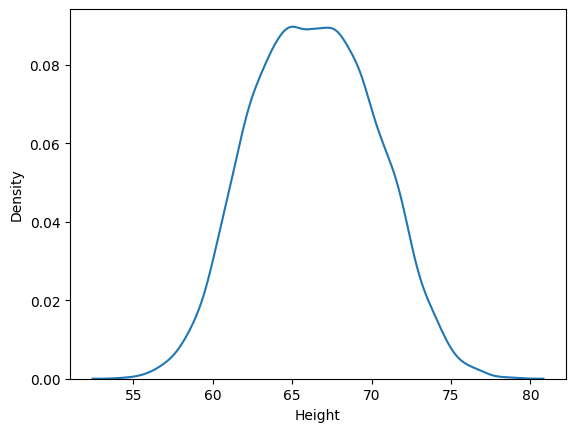

In [8]:
sns.kdeplot(df['Height'])

<Axes: ylabel='Height'>

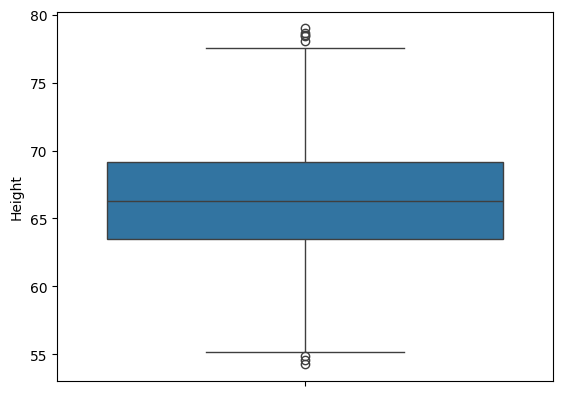

In [9]:
sns.boxplot(df['Height'])

In [10]:
upper_limit = df['Height'].quantile(0.99)
upper_limit

np.float64(74.7857900583366)

In [11]:
lower_limit = df['Height'].quantile(0.01)
lower_limit

np.float64(58.13441158671655)

In [12]:
new_df = df[(df['Height'] <= 74.78) & (df['Height'] >= 58.13)]

In [13]:
new_df

,Gender,Height,Weight
0,Male,73.847017,241.893563
1,Male,68.781904,162.310473
2,Male,74.110105,212.740856
3,Male,71.730978,220.042470
4,Male,69.881796,206.349801
...,...,...,...
9995,Female,66.172652,136.777454
9996,Female,67.067155,170.867906
9997,Female,63.867992,128.475319
9998,Female,69.034243,163.852461


In [16]:
new_df['Height'].describe()

,Height
count,9799.000000
mean,66.363507
std,3.644267
min,58.134496
25%,63.577147
50%,66.317899
75%,69.119859
max,74.767447


<Axes: xlabel='Height', ylabel='Density'>

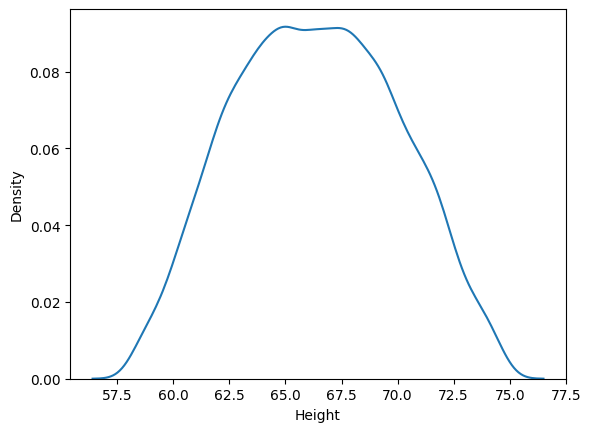

In [18]:
sns.kdeplot(new_df['Height'])

<Axes: ylabel='Height'>

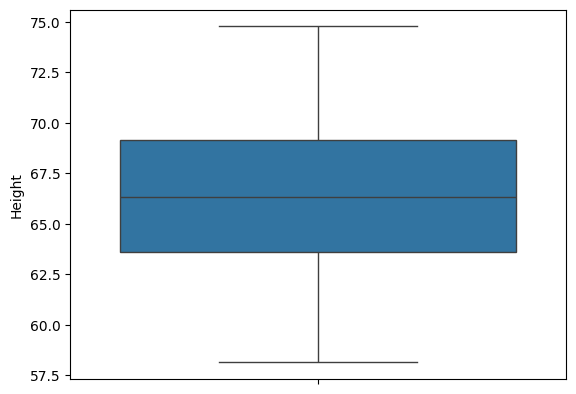

In [19]:
sns.boxplot(new_df['Height'])

In [20]:
# capping - Winsorization
df['Height'] = np.where(
    df['Height'] >= upper_limit,
    upper_limit,
    np.where(
        df['Height'] <= lower_limit,
        lower_limit,
        df['Height']
    )
)

In [22]:
df.shape

(10000, 3)

In [23]:
df['Height'].describe()

,Height
count,10000.000000
mean,66.366281
std,3.795717
min,58.134412
25%,63.505620
50%,66.318070
75%,69.174262
max,74.785790


<Axes: xlabel='Height', ylabel='Density'>

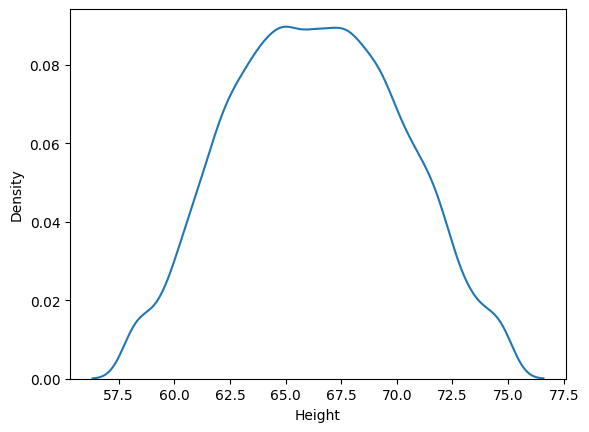

In [25]:
sns.kdeplot(df['Height'])

<Axes: ylabel='Height'>

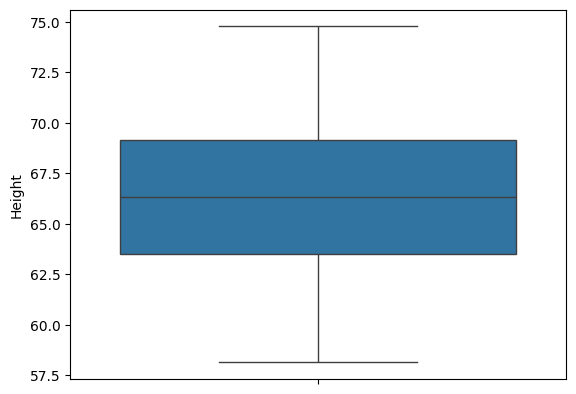

In [26]:
sns.boxplot(df['Height'])